In [1]:

import ctypes

from rapidd.core import calc_new_halo
from numpy import pi, sqrt, exp, piecewise
import halo


In [2]:
from scipy.special import erf

result = erf(1.0)
print(result)

0.8427007929497148


In [3]:
calc_new_halo("SHM_old.dat")

Need to have a table we have


In [4]:
halo.gen_shm_table("SHM.dat")

In [5]:
def eta_shm(vmin, vE, v0, vesc):

    K = v0**3 * pi * (sqrt(pi) * erf(vesc/v0) - 2 * (vesc/v0)* exp(-(vesc/v0)**2))

    def eta1(vmin): return ((v0**2 *pi )/(2*vE*K)) * ( -4 * vE * exp(-(vesc/v0)**2) + sqrt(pi) * v0 *( erf((vmin + vE)/v0) - erf((vmin-vE)/v0) ) )
    def eta2(vmin): return ((v0**2 *pi )/(2*vE*K)) * (  -2 * (vesc - vmin + vE) * exp(-(vesc/v0)**2) + sqrt(pi) * v0*( erf((vmin + vE)/v0) - erf((vmin-vE)/v0) )  )

    conds = [vmin < vesc - vE , (vesc - vE < vmin) & (vmin < vesc + vE)]

    return piecewise(vmin, conds, [eta1, eta2])



In [6]:
eta_shm(1.0, 100.0, 220.0, 544.0)

array(0.00481718)

In [7]:
import matplotlib.pyplot as plt 
import numpy as np

In [8]:
np.sqrt(11.1**2 + (238.0+12.2)**2 + 7.3**2) 

np.float64(250.55246955478208)

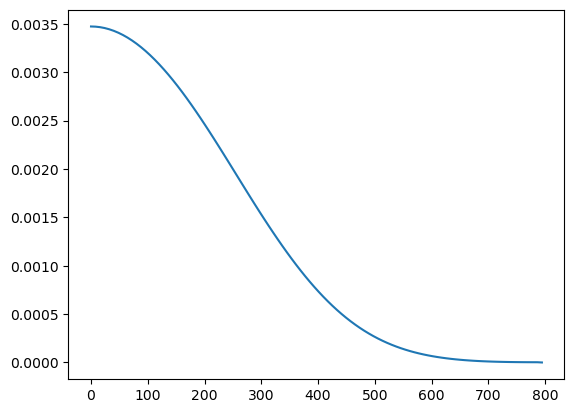

In [15]:
vesc = 544.0
vearth = 250.5
v0 = 238

vend = vesc + vearth

vminspace = np.linspace(0.0, vend, 100)

plt.plot(vminspace, eta_shm(vminspace, vearth, v0, vesc))

In [16]:
eta_values = eta_shm(vminspace, vearth, v0, vesc)


# Open the file for writing
with open("my_eta_output.dat", "w") as f:
    # First line: number of entries and a "1"
    f.write(f"{len(vminspace)} 0\n")
    
    # Write vmin and eta values line by line
    for v, eta in zip(vminspace, eta_values):
        f.write(f"{v:.5E} {eta:.5E}\n")

In [17]:
vmintable, etatable = np.genfromtxt("SHM.dat", skip_header=1, unpack=True)

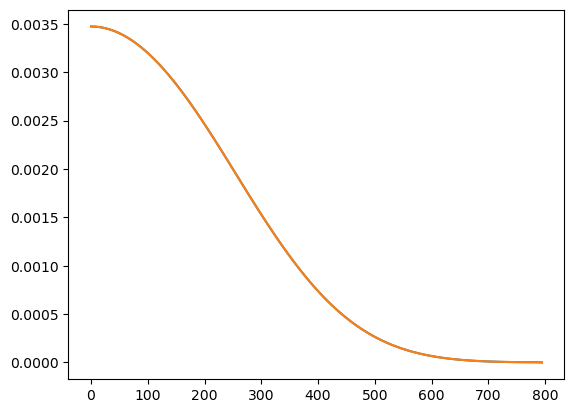

In [18]:
plt.plot(vmintable, etatable)
plt.plot(vminspace, eta_shm(vminspace, vearth, v0, vesc))